## Material de apoio para ser utilizado em sala na aula 01 ##

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
from pathlib import Path

data_candidates = [
    Path("aulas/aula01/archive"),
    Path("aula01/archive"),
    Path("../aula01/archive"),
]
data_dir = next(path for path in data_candidates if path.exists())

dfPayments = pd.read_csv(data_dir / "olist_order_payments_dataset.csv")
dfProducts = pd.read_csv(data_dir / "olist_products_dataset.csv")
dfOrders = pd.read_csv(data_dir / "olist_orders_dataset.csv")
dfOrdersItens = pd.read_csv(data_dir / "olist_order_items_dataset.csv")

In [25]:
#Agrupando as tabelas que serão utlizadas pelas foreign key

df = pd.merge(dfOrders, dfOrdersItens, on='order_id', how='inner')
df = pd.merge(df, dfProducts, on='product_id', how='inner')
df = pd.merge(df, dfPayments, on='order_id', how='inner')
df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,268.0,4.0,500.0,19.0,8.0,13.0,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,178.0,1.0,400.0,19.0,13.0,19.0,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,232.0,1.0,420.0,24.0,19.0,21.0,1,credit_card,3,179.12


In [26]:
#Removendo colunas que não irão ser utilizadas

df = df.drop(columns=[
    'order_id', 'product_id', 'seller_id', 'customer_id',
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'payment_sequential', 'payment_installments',
    'product_name_lenght', 'product_description_lenght',
    'product_photos_qty', 'shipping_limit_date', 'order_status', 'order_item_id'
], errors='ignore')
df.head()

,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_type,payment_value
0,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,credit_card,18.12
1,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,voucher,2.00
2,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,voucher,18.59
3,118.70,22.76,perfumaria,400.0,19.0,13.0,19.0,boleto,141.46
4,159.90,19.22,automotivo,420.0,24.0,19.0,21.0,credit_card,179.12


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   price                  117601 non-null  float64
 1   freight_value          117601 non-null  float64
 2   product_category_name  115903 non-null  object 
 3   product_weight_g       117581 non-null  float64
 4   product_length_cm      117581 non-null  float64
 5   product_height_cm      117581 non-null  float64
 6   product_width_cm       117581 non-null  float64
 7   payment_type           117601 non-null  object 
 8   payment_value          117601 non-null  float64
dtypes: float64(7), object(2)
memory usage: 8.1+ MB


In [28]:
df = df.dropna(axis=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115902 entries, 0 to 117600
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   price                  115902 non-null  float64
 1   freight_value          115902 non-null  float64
 2   product_category_name  115902 non-null  object 
 3   product_weight_g       115902 non-null  float64
 4   product_length_cm      115902 non-null  float64
 5   product_height_cm      115902 non-null  float64
 6   product_width_cm       115902 non-null  float64
 7   payment_type           115902 non-null  object 
 8   payment_value          115902 non-null  float64
dtypes: float64(7), object(2)
memory usage: 8.8+ MB


In [29]:
df['payment_type'].unique()

array(['credit_card', 'voucher', 'boleto', 'debit_card'], dtype=object)

In [30]:
#transformando Variaveis categóricas em numéricas

df['payment_type'] = df['payment_type'].replace({'credit_card': 0, 'voucher': 1, 'boleto': 2, 'debit_card': 3 })
df.head()

/tmp/ipykernel_15254/3549408390.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['payment_type'] = df['payment_type'].replace({'credit_card': 0, 'voucher': 1, 'boleto': 2, 'debit_card': 3 })


,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_type,payment_value
0,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,0,18.12
1,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,1,2.00
2,29.99,8.72,utilidades_domesticas,500.0,19.0,8.0,13.0,1,18.59
3,118.70,22.76,perfumaria,400.0,19.0,13.0,19.0,2,141.46
4,159.90,19.22,automotivo,420.0,24.0,19.0,21.0,0,179.12


In [31]:
categorias = df['product_category_name'].unique()
print(len(categorias))


73


## Exploratory Data Analysis (EDA) - Análise Exploratória de Dados

In [32]:
df.describe().round(2)

,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_type,payment_value
count,115902.00,115902.00,115902.00,115902.00,115902.00,115902.00,115902.00,115902.00
mean,120.93,20.08,2117.68,30.31,16.66,23.11,0.49,173.02
std,184.18,15.87,3785.54,16.22,13.48,11.76,0.85,268.08
min,0.85,0.00,0.00,7.00,2.00,6.00,0.00,0.00
25%,39.90,13.08,300.00,18.00,8.00,15.00,0.00,61.01
50%,74.90,16.32,700.00,25.00,13.00,20.00,0.00,108.20
75%,134.90,21.22,1800.00,38.00,20.00,30.00,1.00,189.72
max,6735.00,409.68,40425.00,105.00,105.00,118.00,3.00,13664.08


Text(0.5, 1.0, 'Distribuição do Preço por tipo de pagamento')

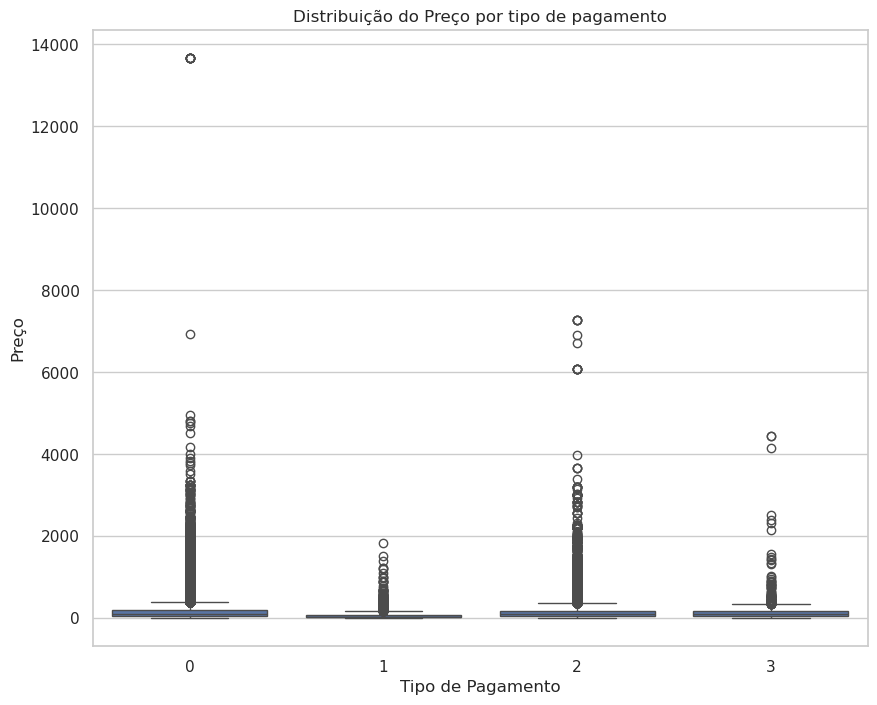

In [33]:
sns.set(style="whitegrid");
fig, ax = plt.subplots(figsize=(10, 8));
sns.boxplot(x=df['payment_type'], y=df['payment_value'], ax=ax);
ax.set_xlabel('Tipo de Pagamento')
ax.set_ylabel('Preço')
plt.title('Distribuição do Preço por tipo de pagamento')

Text(0.5, 1.0, 'Distribuição do Comprimento do Produto')

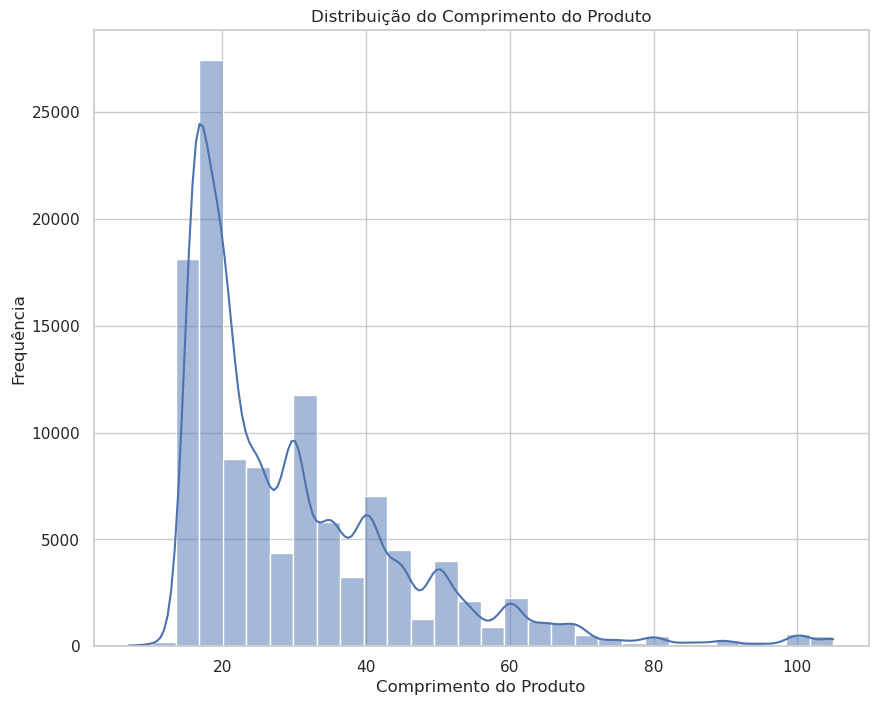

In [50]:
fig, ax = plt.subplots(figsize=(10, 8));
sns.histplot(df['product_length_cm'], bins=30, kde=True, ax=ax);
ax.set_xlabel('Comprimento do Produto')
ax.set_ylabel('Frequência')
plt.title('Distribuição do Comprimento do Produto')

Text(0.5, 1.0, 'Distribuição do Valor do Frete por Peso do Produto')

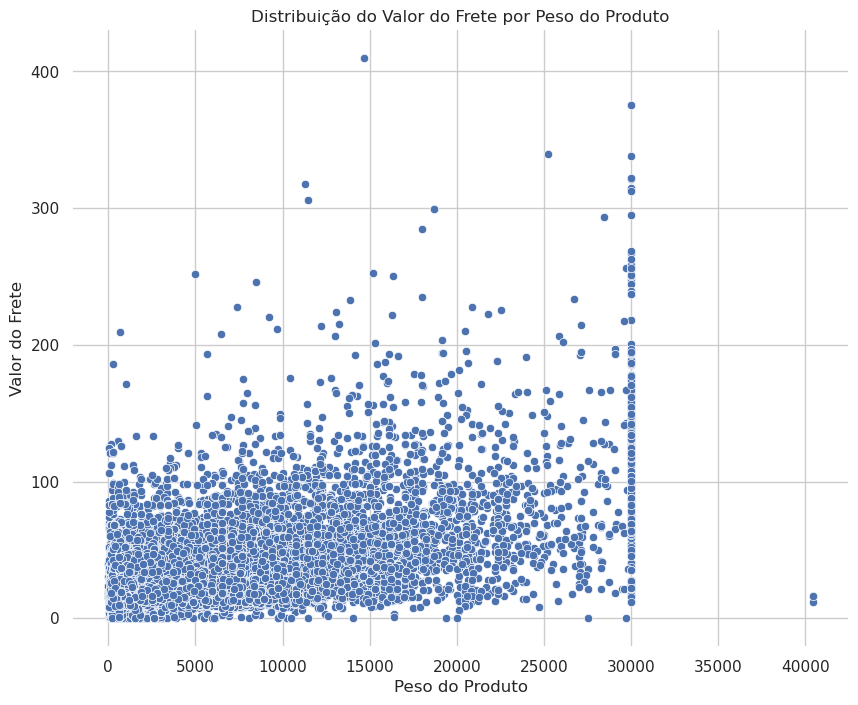

In [38]:
fig, ax = plt.subplots(figsize=(10, 8));
sns.scatterplot(x=df['product_weight_g'], y=df['freight_value'], ax=ax);
sns.despine(fig, left=True, bottom=True)
ax.set_xlabel('Peso do Produto')
ax.set_ylabel('Valor do Frete')
plt.title('Distribuição do Valor do Frete por Peso do Produto')

In [ ]:
productsHightWheight = df[df['product_weight_g'] > 28000]
print(len(productsHightWheight))
print(productsHightWheight[['product_weight_g', 'freight_value', 'product_category_name']].sort_values(by='product_weight_g', ascending=False).head(10))

358
        product_weight_g  freight_value  product_category_name
95426            40425.0          12.06        cama_mesa_banho
34540            40425.0          16.32        cama_mesa_banho
106702           40425.0          16.32        cama_mesa_banho
100112           30000.0          16.85               pet_shop
99542            30000.0          92.16        casa_construcao
74060            30000.0         125.04          esporte_lazer
73808            30000.0         185.71          esporte_lazer
72883            30000.0          61.13     ferramentas_jardim
72775            30000.0          86.66  utilidades_domesticas
72341            30000.0          49.85          esporte_lazer


Text(0.5, 1.0, 'Scatter do Preço por Valor do Frete')

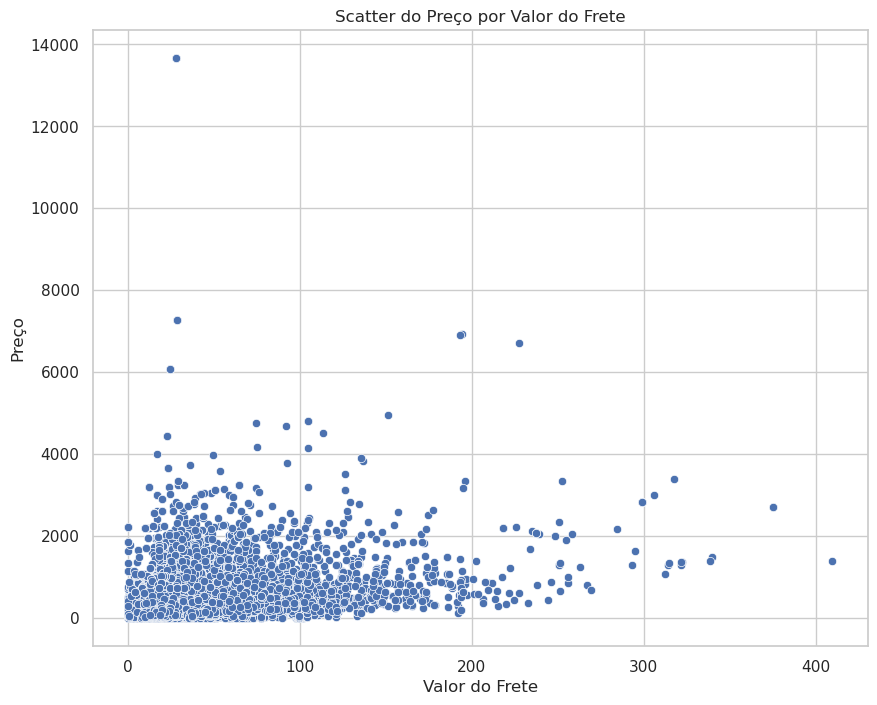

In [46]:
fig, ax = plt.subplots(figsize=(10, 8));
sns.set_style("whitegrid");
sns.scatterplot(x=df['freight_value'], y=df['payment_value'], ax=ax);
ax.set_xlabel('Valor do Frete')
ax.set_ylabel('Preço')
plt.title('Scatter do Preço por Valor do Frete')

Text(0.5, 1.0, 'Distribuição do Comprimento do Produto por Tipo de Pagamento')

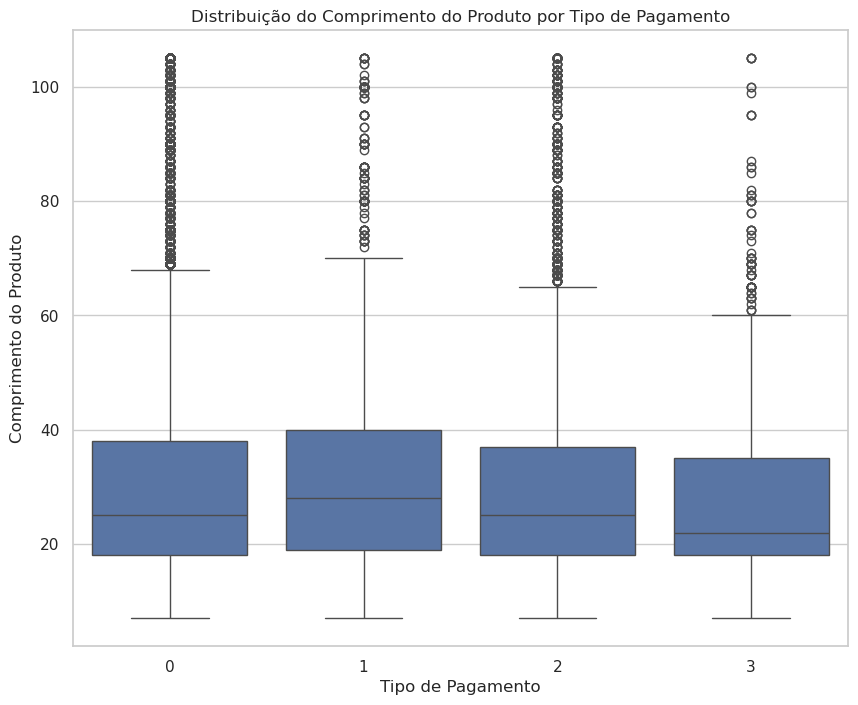

In [59]:
sns.set(style="whitegrid");
fig, ax = plt.subplots(figsize=(10, 8));
sns.boxplot(x=df['payment_type'], y=df['product_length_cm'], ax=ax);
ax.set_xlabel('Tipo de Pagamento')
ax.set_ylabel('Comprimento do Produto')
plt.title('Distribuição do Comprimento do Produto por Tipo de Pagamento') 

Text(0.5, 1.0, 'Mapa de Correlação entre Variáveis')

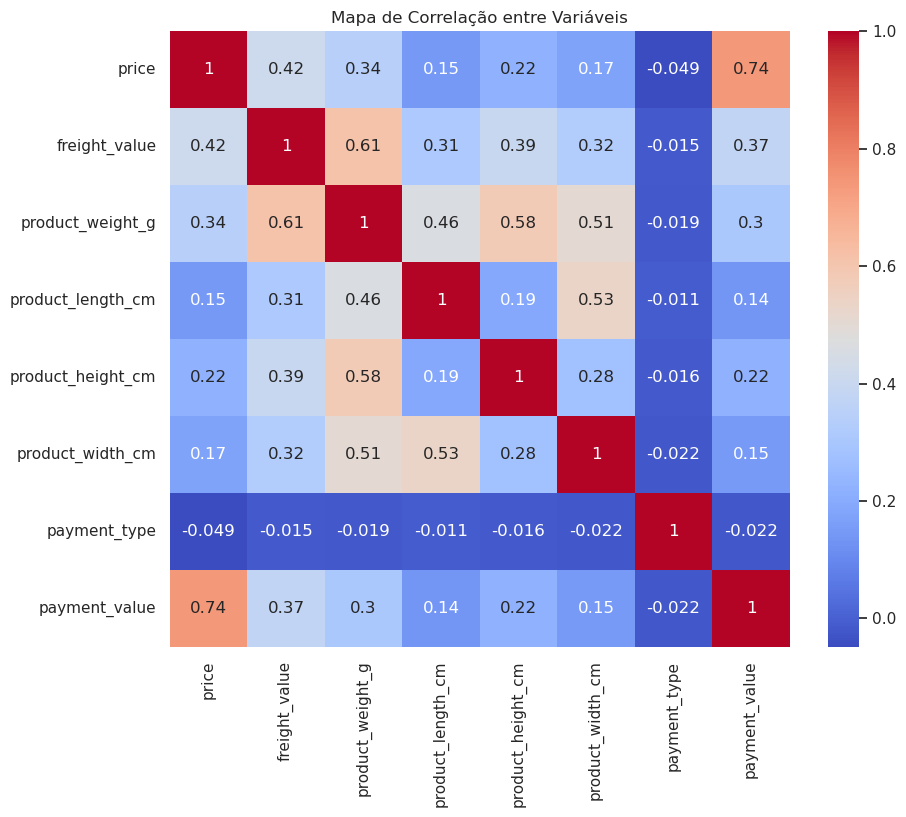

In [55]:
dfHeatMap = df.select_dtypes(include='number')
fig, ax = plt.subplots(figsize=(10, 8));
sns.heatmap(dfHeatMap.corr(), annot=True, cmap='coolwarm', ax=ax)
plt.title('Mapa de Correlação entre Variáveis')